## Bearbetning av läckagedata
*Förberedelse av tidsserie-data för tunnelläckage*

Denna notebook bearbetar rådata för tunnelläckage steg för steg och exporterar bearbetad data för användning i modelleringsnotebooks.

Steg:
1. Importera bibliotek
2. Definiera parametrar
3. Ladda rådata
4. Inspektera rådata per serie
5. Datumkonvertering och filtrering
6. Återindexering till daglig tidsserie
7. Interpolering och fyllning
8. Bearbeta alla serier
9. Inspektera avstånd
10. Exportera bearbetad data

### 0. Importera bibliotek

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

### 1. Definiera parametrar

In [2]:
WELL_NAME = "17U"
data_mapp = "../data"
idx = pd.date_range("2015-01-01", "2021-04-01", freq="D")

print(f"Brunnsnamn: {WELL_NAME}")
print(f"Datumintervall: {idx[0].date()} → {idx[-1].date()}")
print(f"Antal dagar i index: {len(idx)}")

Brunnsnamn: 17U
Datumintervall: 2015-01-01 → 2021-04-01
Antal dagar i index: 2283


### 2. Ladda rådata

In [3]:
df_leak = pd.read_csv(
    os.path.join(data_mapp, "leak_tunnel_gbg.csv"),
    sep=";",
    encoding="cp1252"
)

print(f"Storlek: {df_leak.shape}")
print(f"Kolumner: {df_leak.columns.tolist()}")
df_leak.head(10)

Storlek: (37, 34)
Kolumner: ['Mätobjekt', 'date2', 'Värde [L/min]', 'E04-02', 'Unnamed: 4', 'Unnamed: 5', 'date3', 'Unnamed: 7', 'E04-03', 'Unnamed: 9', 'Unnamed: 10', 'date4', 'Unnamed: 12', 'E04-04', 'Unnamed: 14', 'Unnamed: 15', 'date5', 'Unnamed: 17', 'E04-05', 'Unnamed: 19', 'Unnamed: 20', 'date6', 'Unnamed: 22', 'E04-06', 'Unnamed: 24', 'Unnamed: 25', 'date7', 'Unnamed: 27', 'E04-07', 'Unnamed: 29', 'Unnamed: 30', 'date8', 'Unnamed: 32', 'E04-08']


,Mätobjekt,date2,Värde [L/min],E04-02,Unnamed: 4,Unnamed: 5,date3,Unnamed: 7,E04-03,Unnamed: 9,...,Unnamed: 24,Unnamed: 25,date7,Unnamed: 27,E04-07,Unnamed: 29,Unnamed: 30,date8,Unnamed: 32,E04-08
0,E04-02,2019-07-15,1.11,1.60,NaN,E04-03,2019-08-26,1.85,2.66,NaN,...,NaN,E04-07,2020-07-27,2.02,2.91,NaN,E04-08,2020-10-19,5.02,7.23
1,E04-02,2019-08-26,0.63,0.91,NaN,E04-03,2019-09-23,1.18,1.70,NaN,...,NaN,E04-07,2020-08-10,4.24,6.11,NaN,E04-08,2020-11-02,1.47,2.12
2,E04-02,2019-09-23,0.51,0.73,NaN,E04-03,2019-10-07,1.19,1.71,NaN,...,NaN,E04-07,2020-08-24,3.55,5.11,NaN,E04-08,2020-11-23,2.75,3.96
3,E04-02,2019-10-07,0.43,0.62,NaN,E04-03,2019-11-18,1.31,1.89,NaN,...,NaN,E04-07,2020-09-07,7.23,10.41,NaN,E04-08,2020-11-30,2.40,3.46
4,E04-02,2019-11-18,0.77,1.11,NaN,E04-03,2019-12-02,1.31,1.89,NaN,...,NaN,E04-07,2020-09-21,1.58,2.28,NaN,E04-08,2020-12-14,2.43,3.50
5,E04-02,2019-12-02,0.62,0.90,NaN,E04-03,2019-12-16,0.60,0.86,NaN,...,NaN,E04-07,2020-10-05,4.77,6.87,NaN,E04-08,2021-01-05,3.28,4.72
6,E04-02,2019-12-16,0.73,1.04,NaN,E04-03,2020-01-13,0.50,0.72,NaN,...,NaN,E04-07,2020-10-19,0.00,0.00,NaN,E04-08,2021-01-11,2.75,3.96
7,E04-02,2020-01-13,0.20,0.29,NaN,E04-03,2020-01-27,0.87,1.25,NaN,...,NaN,E04-07,2020-11-02,5.36,7.72,NaN,E04-08,2021-01-25,3.21,4.62
8,E04-02,2020-01-27,1.01,1.45,NaN,E04-03,2020-02-09,0.79,1.14,NaN,...,NaN,E04-07,2020-11-23,5.91,8.51,NaN,E04-08,2021-02-08,2.52,3.63
9,E04-02,2020-02-09,1.64,2.36,NaN,E04-03,2020-02-29,0.21,0.30,NaN,...,NaN,E04-07,2020-11-30,5.70,8.21,NaN,E04-08,2021-01-22,5.48,7.89


### 3. Inspektera rådata per serie

Visar en exempelserie (E04-02) med råvärden och saknade värden.

Antal råmätningar E04-02: 37
Tidsspan: 2019-07-15 → 2021-02-08
Min / Max värde: 0.29 / 5.76 L/min


,E04-02
date2,
2019-07-15,1.60
2019-08-26,0.91
2019-09-23,0.73
2019-10-07,0.62
2019-11-18,1.11
2019-12-02,0.90
2019-12-16,1.04
2020-01-13,0.29
2020-01-27,1.45


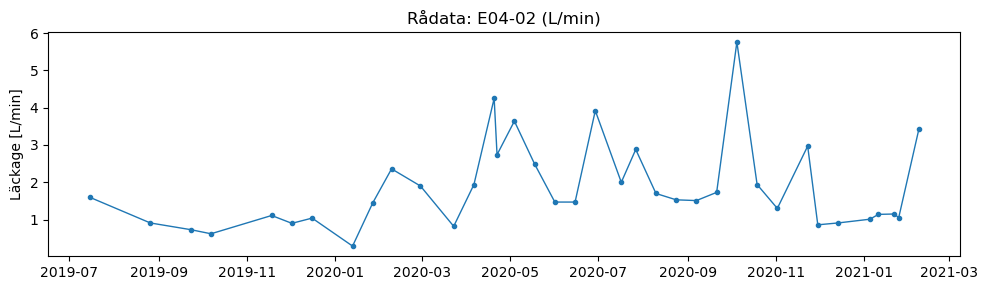

In [4]:
# Exempelserie: E04-02
raw_example = df_leak[["date2", "E04-02"]].dropna().copy()
raw_example["date2"] = pd.to_datetime(raw_example["date2"], errors="coerce")
raw_example = raw_example.dropna(subset=["date2"]).set_index("date2").sort_index()

print(f"Antal råmätningar E04-02: {len(raw_example)}")
print(f"Tidsspan: {raw_example.index[0].date()} → {raw_example.index[-1].date()}")
print(f"Min / Max värde: {raw_example['E04-02'].min():.2f} / {raw_example['E04-02'].max():.2f} L/min")
display(raw_example.head(10))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(raw_example.index, raw_example["E04-02"], marker="o", markersize=3, linewidth=1)
ax.set_title("Rådata: E04-02 (L/min)")
ax.set_ylabel("Läckage [L/min]")
plt.tight_layout()
plt.show()

### 4. Datumkonvertering och filtrering

Konverterar datumkolumnen och filtrerar bort rader där datumet inte kunde tolkas.

In [5]:
# Visa för E04-02 hur NaN uppstår vid datumkonvertering
step = df_leak[["date2", "E04-02"]].dropna().copy()
print(f"Rader efter dropna på series+datum: {len(step)}")

step["date2"] = pd.to_datetime(step["date2"], errors="coerce")
n_bad_dates = step["date2"].isna().sum()
print(f"Rader med ogiltigt datum (NaT): {n_bad_dates}")

step = step.dropna(subset=["date2"])
print(f"Rader kvar efter filtrering: {len(step)}")
display(step.head())

Rader efter dropna på series+datum: 37
Rader med ogiltigt datum (NaT): 0
Rader kvar efter filtrering: 37


,date2,E04-02
0,2019-07-15,1.60
1,2019-08-26,0.91
2,2019-09-23,0.73
3,2019-10-07,0.62
4,2019-11-18,1.11


### 5. Återindexering till daglig tidsserie

Mätdata är glesa — vi återindexerar mot det fullständiga dagliga indexet. Luckor fylls med NaN.

In [6]:
step_indexed = step.set_index("date2")["E04-02"].sort_index().reindex(idx)

n_nan = step_indexed.isna().sum()
print(f"Antal dagar i index: {len(idx)}")
print(f"Antal saknade värden efter återindexering: {n_nan} ({100*n_nan/len(idx):.1f}%)")
display(step_indexed.head(20))

Antal dagar i index: 2283
Antal saknade värden efter återindexering: 2246 (98.4%)


2015-01-01   NaN
2015-01-02   NaN
2015-01-03   NaN
2015-01-04   NaN
2015-01-05   NaN
2015-01-06   NaN
2015-01-07   NaN
2015-01-08   NaN
2015-01-09   NaN
2015-01-10   NaN
2015-01-11   NaN
2015-01-12   NaN
2015-01-13   NaN
2015-01-14   NaN
2015-01-15   NaN
2015-01-16   NaN
2015-01-17   NaN
2015-01-18   NaN
2015-01-19   NaN
2015-01-20   NaN
Freq: D, Name: E04-02, dtype: float64

### 6. Interpolering och fyllning

Luckor fylls med linjär interpolering. Värden utanför mätperioden (t.ex. i början) sätts till 0.

Saknade värden efter interpolering: 0
Min / Max efter bearbetning: 0.00 / 5.76 L/min


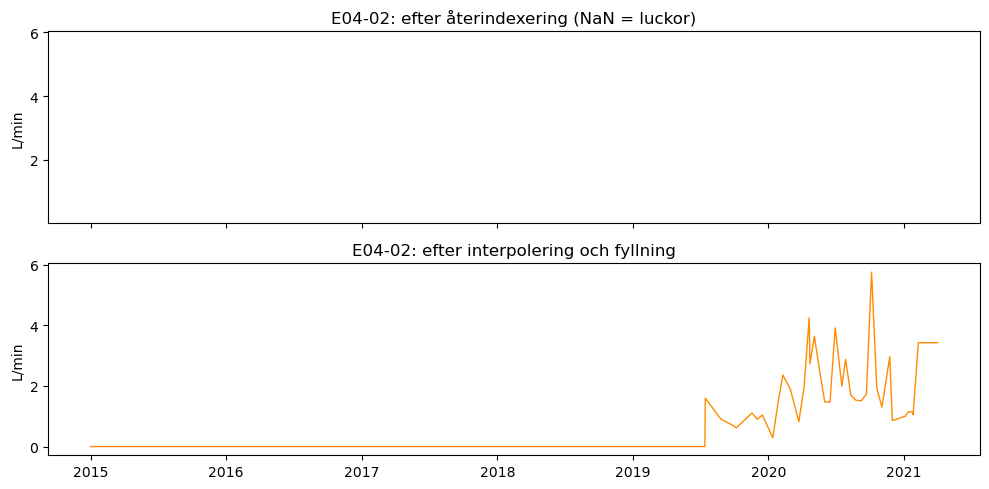

In [7]:
step_interp = step_indexed.interpolate("linear").fillna(0.0).asfreq("D")

print(f"Saknade värden efter interpolering: {step_interp.isna().sum()}")
print(f"Min / Max efter bearbetning: {step_interp.min():.2f} / {step_interp.max():.2f} L/min")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(step_indexed.index, step_indexed.values, color="steelblue", linewidth=1)
axes[0].set_title("E04-02: efter återindexering (NaN = luckor)")
axes[0].set_ylabel("L/min")
axes[1].plot(step_interp.index, step_interp.values, color="darkorange", linewidth=1)
axes[1].set_title("E04-02: efter interpolering och fyllning")
axes[1].set_ylabel("L/min")
plt.tight_layout()
plt.show()

### 7. Bearbeta alla serier

Samma steg appliceras på alla 7 läckageserier (E04-02 till E04-08).

In [8]:
def build_leakage(series, date_col):
    return (
        df_leak[[date_col, series]]
        .dropna()
        .assign(**{date_col: lambda d: pd.to_datetime(d[date_col], errors="coerce")})
        .dropna(subset=[date_col])
        .set_index(date_col)[series]
        .sort_index()
        .reindex(idx)
        .interpolate("linear")
        .fillna(0.0)
        .asfreq("D")
        .rename(series)
    )

L_stresses = [
    build_leakage(f"E04-0{i}", f"date{i}")
    for i in range(2, 9)
]

df_processed = pd.concat(L_stresses, axis=1)
print(f"Antal serier: {df_processed.shape[1]}")
print(f"Kolumner: {df_processed.columns.tolist()}")
print(f"Saknade värden per serie:")
print(df_processed.isna().sum())
display(df_processed.head(10))

Antal serier: 7
Kolumner: ['E04-02', 'E04-03', 'E04-04', 'E04-05', 'E04-06', 'E04-07', 'E04-08']
Saknade värden per serie:
E04-02    0
E04-03    0
E04-04    0
E04-05    0
E04-06    0
E04-07    0
E04-08    0
dtype: int64


,E04-02,E04-03,E04-04,E04-05,E04-06,E04-07,E04-08
2015-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0


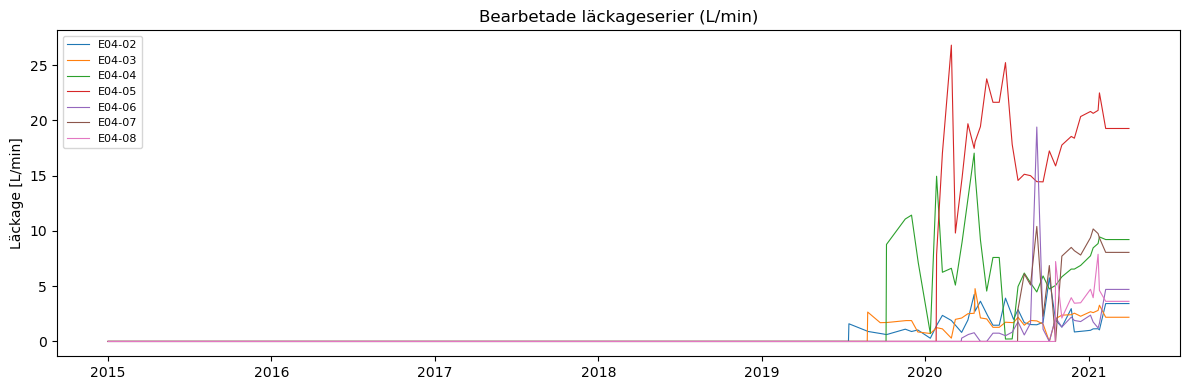

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
for col in df_processed.columns:
    ax.plot(df_processed.index, df_processed[col], linewidth=0.8, label=col)
ax.set_title("Bearbetade läckageserier (L/min)")
ax.set_ylabel("Läckage [L/min]")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 8. Inspektera avstånd

Avstånd (meter) från varje läckagesektion till brunnen används som vikter i WellModel. Dessa beräknas med hjälp av GIS (visas inte här).

In [ ]:
df_dist = (
    pd.read_csv(
        os.path.join(data_mapp, "leak_dist_tunnel_gbg.csv"),
        sep=";",
        index_col="distance"
    )
    .sort_index()
    .round(2) # runda avstånd till 2 decimaler
)

print(f"Tillgängliga brunnar i avståndsfilen: {df_dist.columns.tolist()}")
print(f"Tillgängliga sektioner: {df_dist.index.tolist()}")
display(df_dist)

# Kontrollera matchning mot bearbetade serier
serier = df_processed.columns.tolist()
sektioner_i_dist = df_dist.index.tolist()
saknas_i_dist = [s for s in serier if s not in sektioner_i_dist]
print(f"\nSerier i bearbetad data: {serier}")
if saknas_i_dist:
    print(f"VARNING: Följande serier saknar avstånd i avståndsfilen: {saknas_i_dist}")
else:
    print("Alla serier har matchande avstånd.")


Tillgängliga brunnar i avståndsfilen: ['17U']
Tillgängliga sektioner: ['E04-02', 'E04-03', 'E04-04', 'E04-05', 'E04-06', 'E04-07', 'E04-08']


,17U
distance,
E04-02,248.48
E04-03,249.99
E04-04,270.95
E04-05,323.21
E04-06,389.67
E04-07,476.91
E04-08,603.05



Serier i bearbetad data: ['E04-02', 'E04-03', 'E04-04', 'E04-05', 'E04-06', 'E04-07', 'E04-08']
Alla serier har matchande avstånd.


### 9. Exportera bearbetad data

In [12]:
output_path = os.path.join(data_mapp, "processed_leakage.csv")
df_processed.to_csv(output_path, sep=";", encoding="utf-8")

print(f"Exporterad: {output_path}")
print(f"Storlek: {df_processed.shape[0]} rader × {df_processed.shape[1]} kolumner")
print(f"Kolumner: {df_processed.columns.tolist()}")

Exporterad: ../data\processed_leakage.csv
Storlek: 2283 rader × 7 kolumner
Kolumner: ['E04-02', 'E04-03', 'E04-04', 'E04-05', 'E04-06', 'E04-07', 'E04-08']
